In [4]:
import numpy as np
import matplotlib.pyplot as plt


def primitive_to_conserved(rho, u, v, p, gamma):
    E = p / (gamma - 1.0) + 0.5 * rho * (u**2 + v**2)
    return np.stack((rho, rho * u, rho * v, E))


def conserved_to_primitive(U, gamma):
    rho = U[0]
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = (gamma - 1.0) * (E - 0.5 * rho * (u**2 + v**2))
    return rho, u, v, p


def gradient(q, dx):
    qx = (np.roll(q, -1, axis=0) - np.roll(q, 1, axis=0)) / (2.0 * dx)
    qy = (np.roll(q, -1, axis=1) - np.roll(q, 1, axis=1)) / (2.0 * dx)
    return qx, qy


def physical_flux(rho, u, v, p, gamma, axis="x"):
    E = p / (gamma - 1.0) + 0.5 * rho * (u**2 + v**2)
    if axis == "x":
        return np.stack((rho * u,
                         rho * u**2 + p,
                         rho * u * v,
                         (E + p) * u))
    return np.stack((rho * v,
                     rho * u * v,
                     rho * v**2 + p,
                     (E + p) * v))


def rusanov_flux(WL, WR, gamma, axis="x"):
    rhoL, uL, vL, pL = WL
    rhoR, uR, vR, pR = WR

    UL = primitive_to_conserved(rhoL, uL, vL, pL, gamma)
    UR = primitive_to_conserved(rhoR, uR, vR, pR, gamma)
    FL = physical_flux(rhoL, uL, vL, pL, gamma, axis)
    FR = physical_flux(rhoR, uR, vR, pR, gamma, axis)

    cL = np.sqrt(gamma * pL / rhoL)
    cR = np.sqrt(gamma * pR / rhoR)
    unL = uL if axis == "x" else vL
    unR = uR if axis == "x" else vR
    alpha = np.maximum(np.abs(unL) + cL, np.abs(unR) + cR)

    return 0.5 * (FL + FR) - 0.5 * alpha * (UR - UL)


def step(U, dx, dt, gamma):
    rho, u, v, p = conserved_to_primitive(U, gamma)

    # Piecewise-linear reconstruction: central slopes on a periodic grid.
    rho_x, rho_y = gradient(rho, dx)
    u_x, u_y = gradient(u, dx)
    v_x, v_y = gradient(v, dx)
    p_x, p_y = gradient(p, dx)

    # Half-step predictor from the primitive Euler equations.
    rho_h = rho - 0.5 * dt * (u * rho_x + rho * u_x + v * rho_y + rho * v_y)
    u_h = u - 0.5 * dt * (u * u_x + v * u_y + p_x / rho)
    v_h = v - 0.5 * dt * (u * v_x + v * v_y + p_y / rho)
    p_h = p - 0.5 * dt * (gamma * p * (u_x + v_y) + u * p_x + v * p_y)

    # States at x-faces i+1/2: left state from cell i, right state from i+1.
    WLx = (rho_h + 0.5 * dx * rho_x,
           u_h + 0.5 * dx * u_x,
           v_h + 0.5 * dx * v_x,
           p_h + 0.5 * dx * p_x)
    WRx = tuple(np.roll(q - 0.5 * dx * dq, -1, axis=0)
                for q, dq in zip((rho_h, u_h, v_h, p_h),
                                 (rho_x, u_x, v_x, p_x)))

    # States at y-faces j+1/2.
    WLy = (rho_h + 0.5 * dx * rho_y,
           u_h + 0.5 * dx * u_y,
           v_h + 0.5 * dx * v_y,
           p_h + 0.5 * dx * p_y)
    WRy = tuple(np.roll(q - 0.5 * dx * dq, -1, axis=1)
                for q, dq in zip((rho_h, u_h, v_h, p_h),
                                 (rho_y, u_y, v_y, p_y)))

    Fx = rusanov_flux(WLx, WRx, gamma, axis="x")
    Fy = rusanov_flux(WLy, WRy, gamma, axis="y")

    U = U - (dt / dx) * (Fx - np.roll(Fx, 1, axis=1))
    U = U - (dt / dx) * (Fy - np.roll(Fy, 1, axis=2))
    return U

def plot_and_save_rho(rho, t: float = 2.0, path_to_store: str = './results/', do_store: bool = True):
    fig, ax = plt.subplots(1,1,figsize=(5, 5))
    im = ax.imshow(rho.T, origin="lower", extent=(0, 1, 0, 1), cmap="viridis")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    t_string = f"{t:.2f}"
    ax.set_title(f"Kelvin-Helmholtz instability \n $\\rho(x,y,t={t_string})$")
    #fig.colorbar(im, ax=ax, label=r"$\rho$")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    fig.tight_layout()

    if do_store:
        t_string = t_string.replace('.', ':')
        fig.savefig(f'./results/finitevolume_{t_string}.png',dpi=100)
    return fig

def simulate(N=128, t_end=2.0, cfl=0.4, gamma=5.0 / 3.0, log_every: int = 10):
    dx = 1.0 / N
    xc = (np.arange(N) + 0.5) * dx
    X, Y = np.meshgrid(xc, xc, indexing="ij")

    # Kelvin--Helmholtz initial condition.
    strip = np.abs(Y - 0.5) < 0.25
    rho = 1.0 + strip.astype(float)
    u = -0.5 + strip.astype(float)
    sigma = 0.05 / np.sqrt(2.0)
    v = 0.1 * np.sin(4.0 * np.pi * X) * (
        np.exp(-(Y - 0.25) ** 2 / (2.0 * sigma**2))
        + np.exp(-(Y - 0.75) ** 2 / (2.0 * sigma**2))
    )
    p = 2.5 * np.ones_like(rho)

    U = primitive_to_conserved(rho, u, v, p, gamma)
    t = 0.0
    counter = 0
    while t < t_end:
        # compute 
        rho, u, v, p = conserved_to_primitive(U, gamma)
        if np.min(rho) <= 0 or np.min(p) <= 0:
            raise RuntimeError(f"Nonphysical state at t={t}: min rho={rho.min()}, min p={p.min()}")
        # Update
        c = np.sqrt(gamma * p / rho)
        dt = cfl * np.min(dx / (c + np.sqrt(u**2 + v**2)))
        dt = min(dt, t_end - t)
        U = step(U, dx, dt, gamma)
        t += dt
        counter += 1

    return X, Y, conserved_to_primitive(U, gamma)

In [ ]:
X, Y, (rho, u, v, p) = simulate(t_end=2.0, log_every=-1)

In [ ]:
_ = plot_and_save_rho(rho, t=2.0)

Doing t=0.0
Done
Doing t=0.25
Done
Doing t=0.5
Done
Doing t=0.75
Done
Doing t=1.0
Done
Doing t=2.0
Done


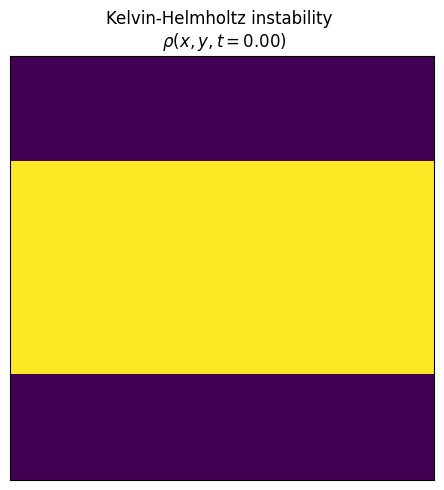

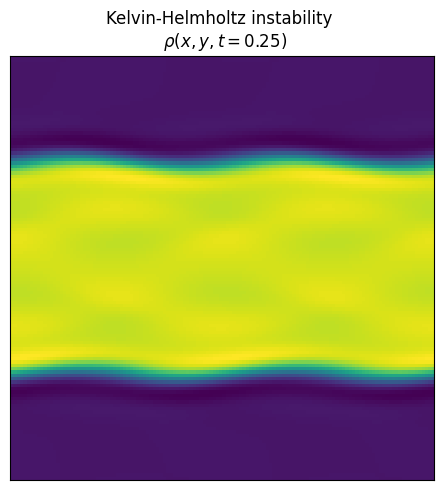

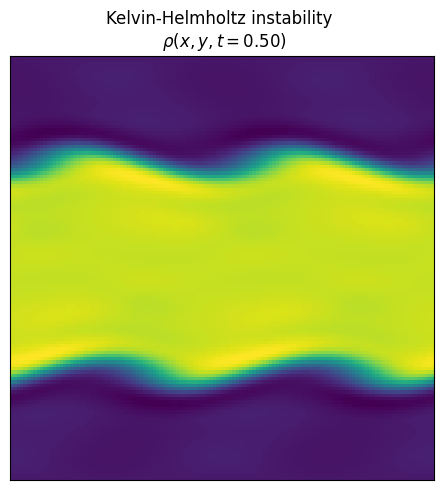

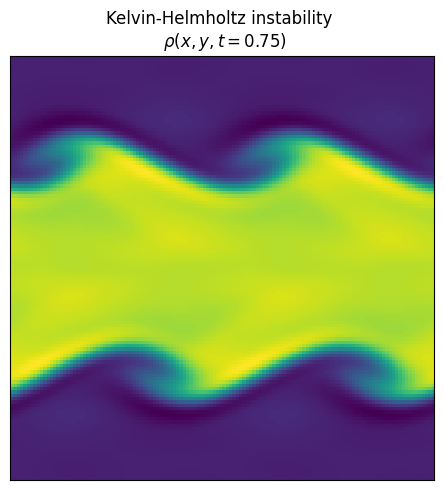

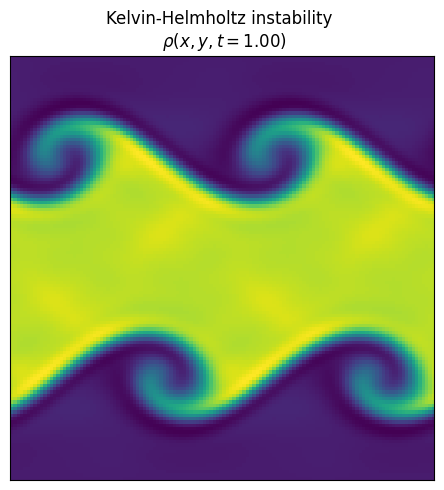

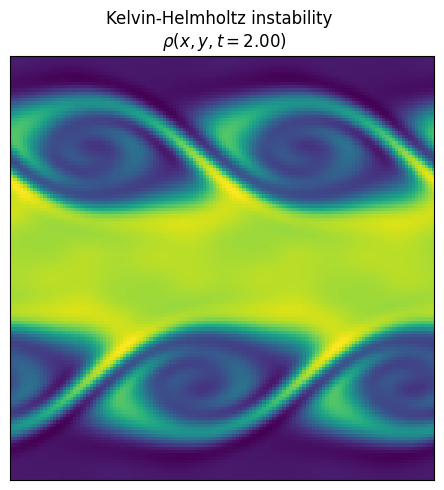

In [6]:
rhos = []
t_steps = [0.0, 0.25, 0.5, 0.75, 1.0, 2.0]
for t in t_steps:
    print(f"Doing t={t}")
    X, Y, (rho, u, v, p) = simulate(t_end=t)
    _ = plot_and_save_rho(rho, t=t)
    rhos.append(rho)
    print('Done')

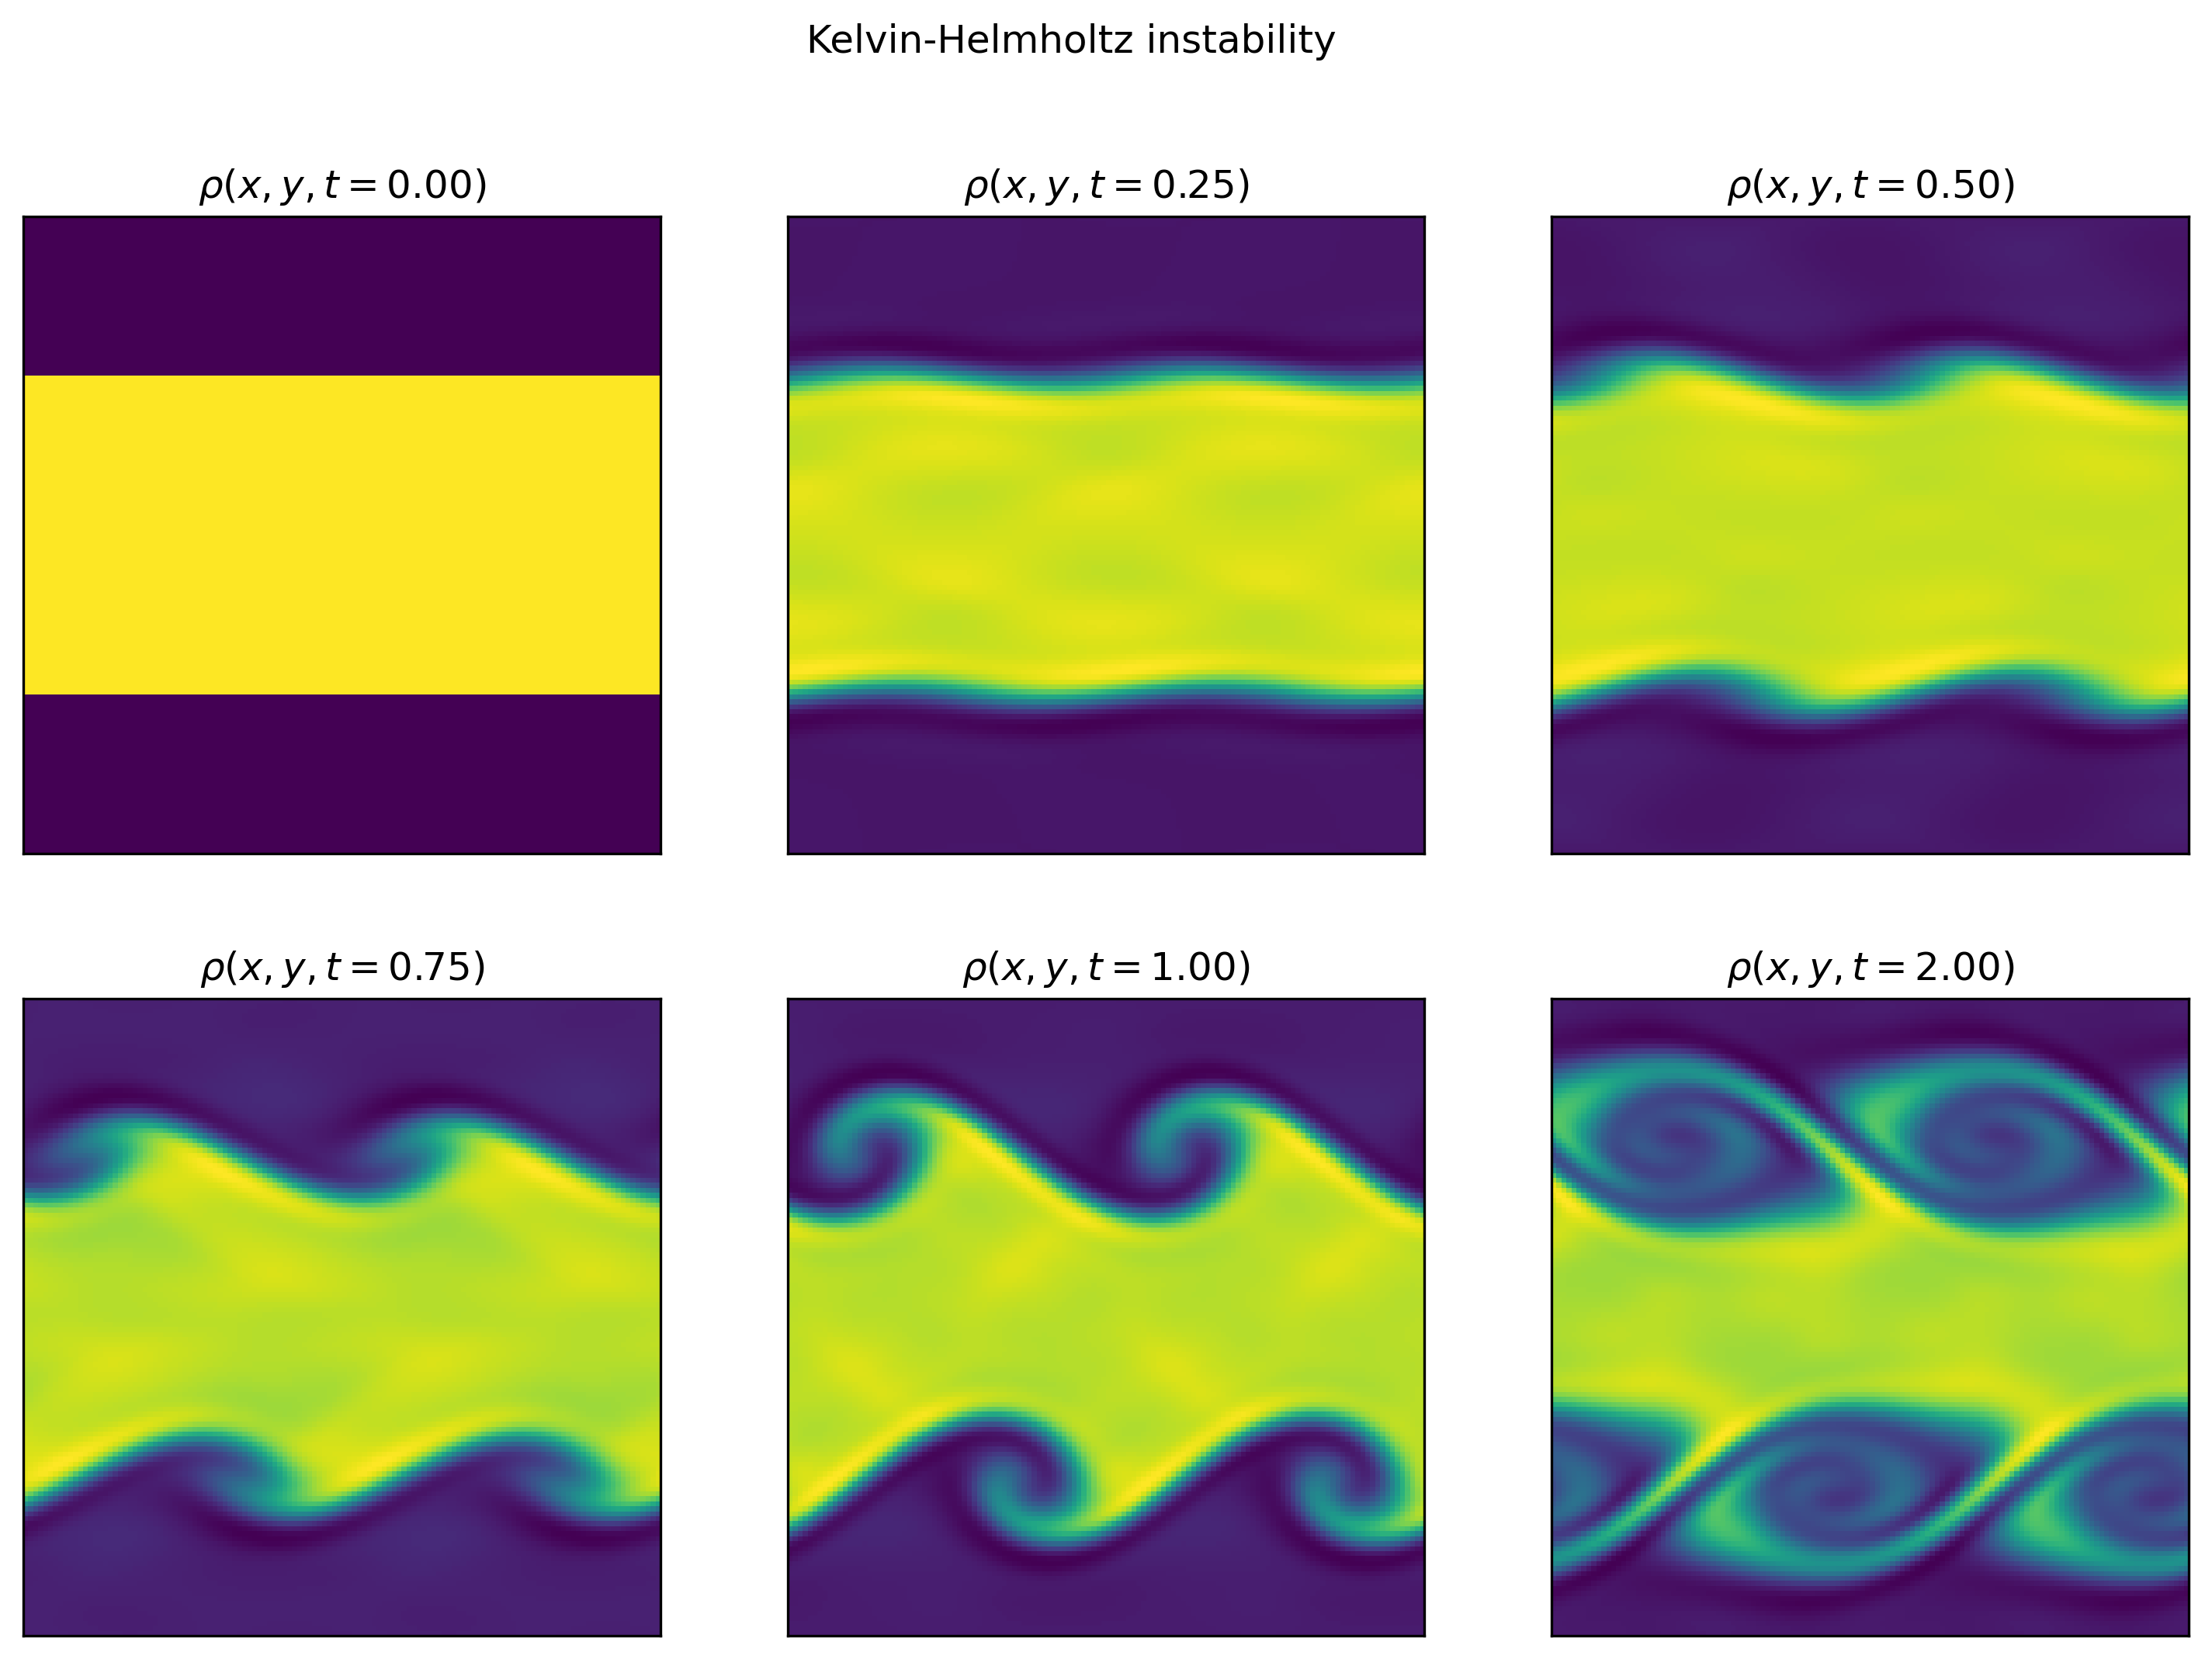

In [11]:
fig, axs = plt.subplots(2,3,dpi=300, figsize=(12,8))
fig.suptitle('Kelvin-Helmholtz instability')
for idx, t in enumerate(t_steps):
    ax = axs[idx//3, idx%3]
    im = ax.imshow(rhos[idx].T, origin="lower", extent=(0, 1, 0, 1), cmap="viridis")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    t_string = f"{t:.2f}"
    ax.set_title(f"$\\rho(x,y,t={t_string})$")
    #fig.colorbar(im, ax=ax, label=r"$\rho$")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)